# Numeric Forecast Scenarios - Cumulative Distribution Analysis

**Date**: January 28, 2026  
**Purpose**: Visualize cumulative distributions of forecast scenarios for numeric questions  
**Data Source**: JSON scenario files from `all_forecast_summaries/`

## Questions Analyzed
- 41614 - unknown tournament
- 41619 - unknown tournament  
- 41750 - Spring AIB 2026
- 41752 - Spring AIB 2026
- 41871 - Spring AIB 2026
- 41875 - Spring AIB 2026

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import probscale

# For Gaussian Process Regression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

In [2]:
# Data loading and processing functions

def load_scenario_data(question_id, data_path):
    """
    Load scenario data from JSON file for a numeric question.
    Returns the raw scenario values and metadata.
    """
    # Find the JSON file for this question
    json_files = list(data_path.glob(f"{question_id}_*_scenarios_*.json"))
    
    if not json_files:
        print(f"Warning: No scenario file found for question {question_id}")
        return None, None
    
    json_file = json_files[0]  # Take first match
    
    with open(json_file, 'r') as f:
        data = json.load(f)
    
    # Extract raw scenario values
    raw_values = data['scenarios']['raw_values']
    metadata = data['metadata']
    aggregated = data['aggregated_result']
    summary = data['summary']
    
    return {
        'raw_values': raw_values,
        'metadata': metadata,
        'aggregated': aggregated,
        'summary': summary,
        'filename': json_file.name
    }

def make_sorted_data(raw_values):
    """
    Sort the raw scenario values.
    """
    return sorted(raw_values)

def make_percentiles(sorted_data):
    """
    Calculate percentile values for each data point.
    """
    pctl = [100 * i/(1 + len(sorted_data)) for i, row in enumerate(sorted_data)]
    return pctl

def make_gpr_model(sorted_data, pctl):
    """
    Fit a Gaussian Process Regression model to smooth the cumulative distribution.
    """
    X = np.array(pctl).reshape(-1, 1)
    y = np.array(sorted_data)
    
    # Define the kernel: smooth base + noise for blockiness
    smooth_kernel = C(1.0, (1e-3, 1e5)) * RBF(20.0, (1e-2, 1e2))
    kernel = smooth_kernel + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e2))
    
    # Fit the model
    gp_model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
    gp_model.fit(X, y)
    
    return gp_model

def calc_gpr_percentiles(gp_model, pctl_values):
    """
    Calculate GPR predictions for given percentiles.
    """
    X = np.array(pctl_values).reshape(-1, 1)
    y_pred, sigma_pred = gp_model.predict(X, return_std=True)
    return y_pred, sigma_pred

def calc_gpr_p50(gp_model):
    """
    Calculate the GPR median (p50) value.
    """
    return gp_model.predict(np.array([50]).reshape(-1, 1))[0]

In [3]:
# Configuration

# Numeric question IDs to analyze
question_ids = [41614, 41619, 41750, 41752, 41871, 41875]

# Path to forecast summaries
data_path = Path("C:/Users/Donni/projects/metac_bot_Spring_2026/all_forecast_summaries")

# Plot configuration
use_gpr_smoothing = True  # Set to False to plot raw scenarios only
use_prob_scale = True     # Use probability scale for axes

### Forecast Distribution Notes

The forecast scenarios represent individual LLM predictions from a 3×3 world matrix (optimistic/baseline/pessimistic × other axes). With 4 LLM calls, we expect 36 individual scenario values.

#### Gaussian Process Regression (GPR) Smoothing

GPR can be applied to smooth through the empirical cumulative distribution:
- Fits a smooth curve through the scenario percentiles
- Handles noise and blockiness in the raw predictions
- Provides uncertainty estimates (sigma)

References:
- Gaussian Process Regression: https://scikit-learn.org/stable/modules/gaussian_process.html
- Quick Start Guide: https://www.geeksforgeeks.org/machine-learning/quick-start-to-gaussian-process-regression/

In [4]:
# Plotting function

def plot_forecast_distribution(question_id, sorted_data, pctl, gp_model=None, 
                               metadata=None, summary=None, aggregated=None,
                               use_prob_scale=True):
    """
    Plot the cumulative distribution of forecast scenarios.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Question info
    q_text = metadata.get('question_text', 'Unknown')[:60] + "..."
    tournament = metadata.get('tournament', 'Unknown')
    units = metadata.get('units', '')
    
    # Plot raw scenarios
    ax.scatter(sorted_data, pctl, s=20, alpha=0.6, label='Raw scenarios', color='steelblue')
    
    # Plot GPR fit if available
    if gp_model is not None:
        predicted_val, sigma = calc_gpr_percentiles(gp_model, pctl)
        gpr_p50 = calc_gpr_p50(gp_model)
        
        ax.plot(predicted_val, pctl, linewidth=2, alpha=0.7, 
                label=f'GPR fit (p50 = {gpr_p50:.2f})', color='darkorange')
        
        # Add confidence interval
        ax.fill_betweenx(pctl, predicted_val - 1.96*sigma, predicted_val + 1.96*sigma, 
                        alpha=0.15, color='darkorange', label='95% CI')
    
    # Add summary statistics
    if summary:
        stats_text = f"Min: {summary['min_value']:.2f}\n"
        stats_text += f"Median: {summary['median_value']:.2f}\n"
        stats_text += f"Mean: {summary['mean_value']:.2f}\n"
        stats_text += f"Max: {summary['max_value']:.2f}\n"
        stats_text += f"Std: {summary['std_value']:.2f}"
        
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
               verticalalignment='top', fontsize=9,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # Formatting
    ax.set_xlabel(f"Forecast Value ({units})" if units else "Forecast Value", fontsize=11)
    ax.set_ylabel("Percentile", fontsize=11)
    ax.set_title(f"Question {question_id}: {q_text}\n{tournament}", fontsize=12, pad=15)
    
    if use_prob_scale:
        ax.set_yscale('prob')
        ax.set_ylim(bottom=1, top=99)
    else:
        ax.set_ylim(bottom=0, top=100)
    
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=9)
    
    plt.tight_layout()
    plt.show()

## Load and Process All Questions

This cell loads the scenario data for all numeric questions and prepares it for plotting.

In [5]:
# Load all question data

all_question_data = {}

print("Loading scenario data for numeric questions...")
print("=" * 80)

for qid in question_ids:
    data = load_scenario_data(qid, data_path)
    
    if data is None:
        continue
    
    # Store the data
    all_question_data[qid] = data
    
    # Print summary
    print(f"Question {qid}:")
    print(f"  File: {data['filename']}")
    print(f"  Scenarios: {len(data['raw_values'])}")
    print(f"  Range: {data['summary']['min_value']:.2f} - {data['summary']['max_value']:.2f}")
    print(f"  Median: {data['summary']['median_value']:.2f}")
    print()

print(f"✓ Loaded {len(all_question_data)} questions successfully")

Loading scenario data for numeric questions...
Question 41614:
  File: 41614_unknown_scenarios_1.json
  Scenarios: 36
  Range: 4.25 - 5.30
  Median: 4.71

Question 41619:
  File: 41619_unknown_scenarios_1.json
  Scenarios: 36
  Range: 4.25 - 5.55
  Median: 4.82

Question 41750:
  File: 41750_spring_aib_2026_scenarios_1.json
  Scenarios: 36
  Range: 14.00 - 15.50
  Median: 14.75

Question 41752:
  File: 41752_spring_aib_2026_scenarios_1.json
  Scenarios: 36
  Range: 429.50 - 435.00
  Median: 432.25

Question 41871:
  File: 41871_spring_aib_2026_scenarios_1.json
  Scenarios: 36
  Range: 6000000000.00 - 8000000000.00
  Median: 6975000000.00

Question 41875:
  File: 41875_spring_aib_2026_scenarios_1.json
  Scenarios: 36
  Range: 36.00 - 47.00
  Median: 41.85

✓ Loaded 6 questions successfully


## Plot Cumulative Distributions

Generate cumulative distribution plots for each numeric question.

Generating cumulative distribution plots...



C:\Users\Donni\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


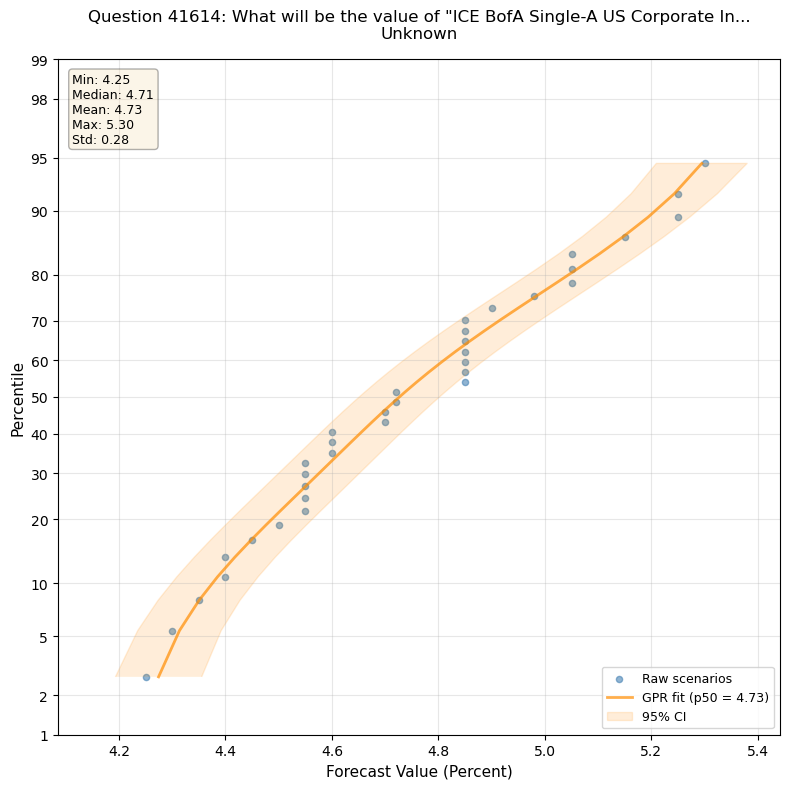

C:\Users\Donni\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


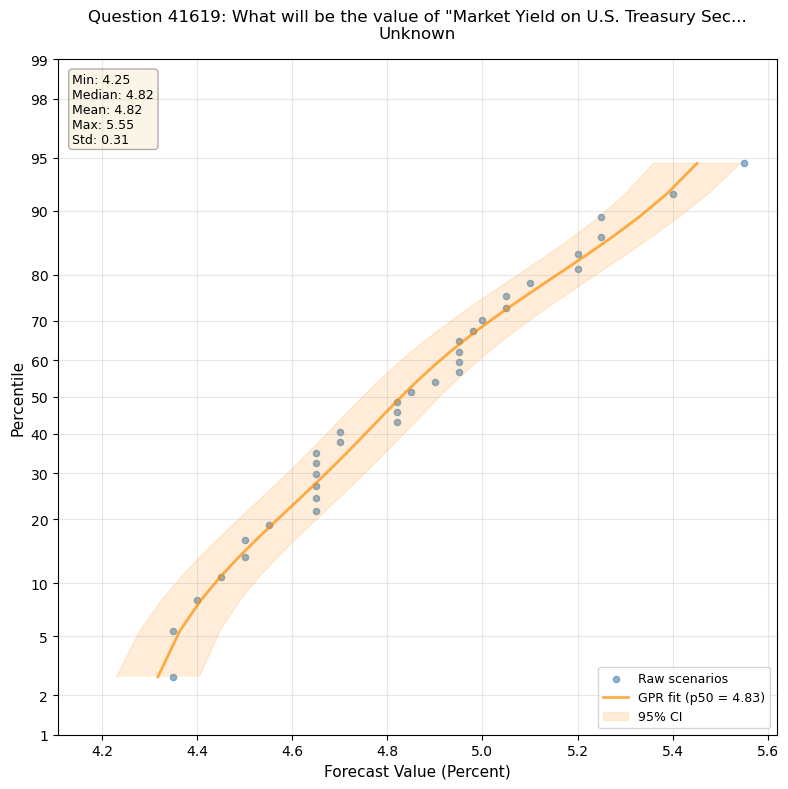

C:\Users\Donni\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


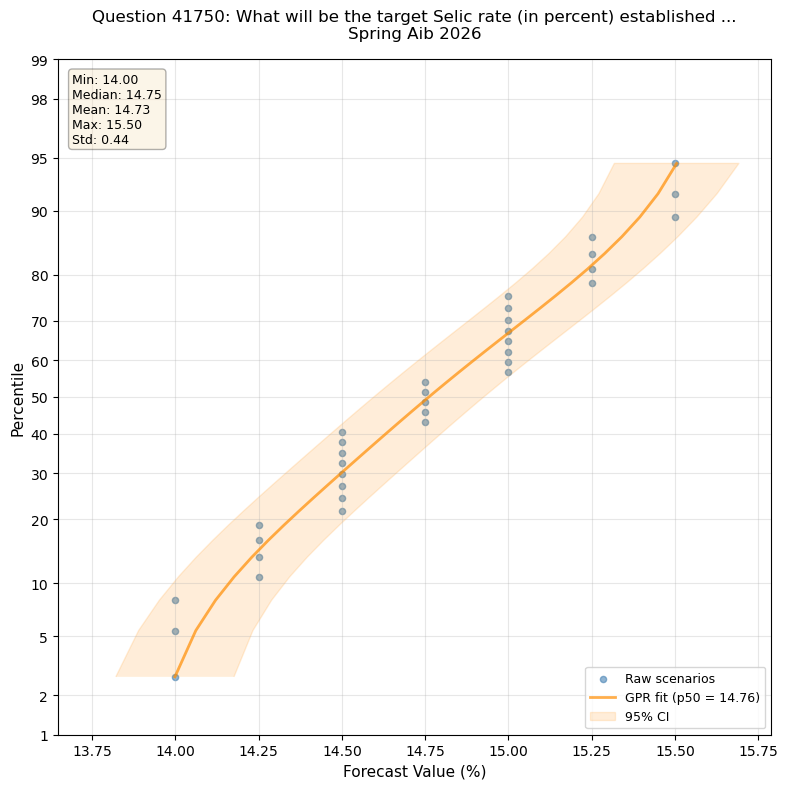

C:\Users\Donni\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


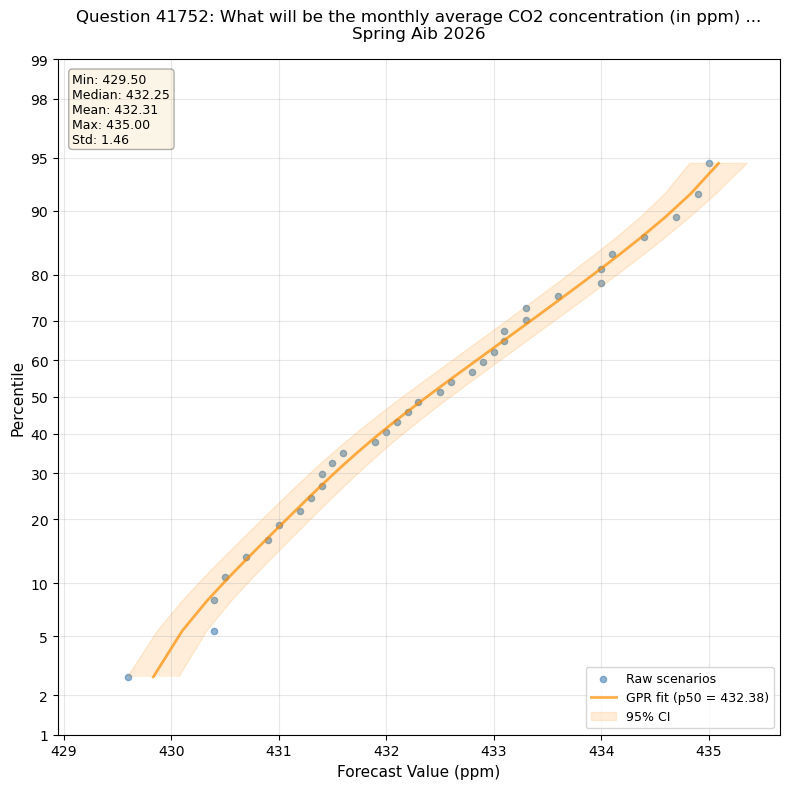

C:\Users\Donni\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Donni\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


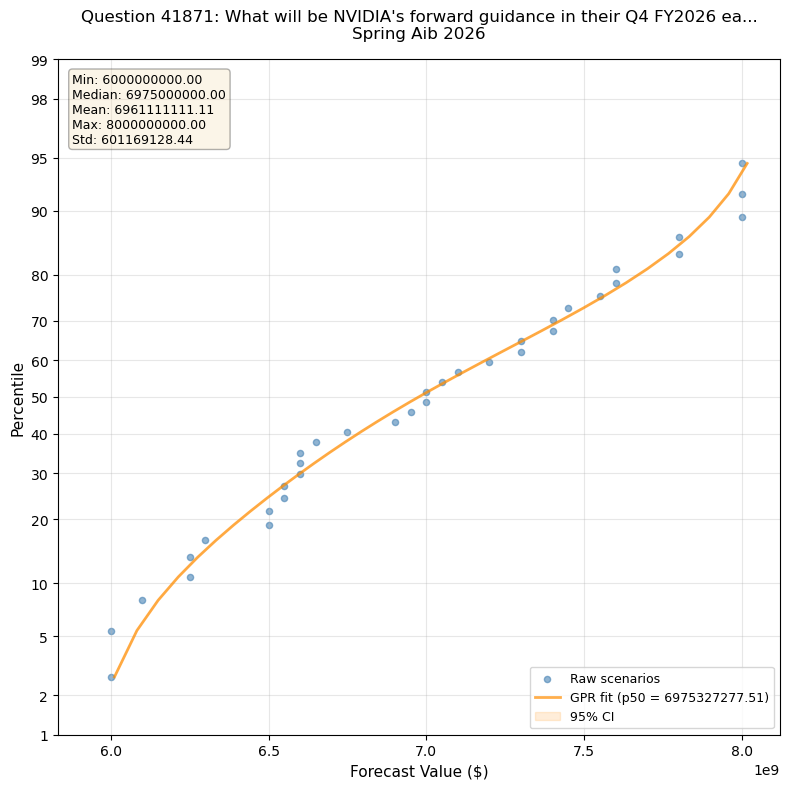

C:\Users\Donni\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


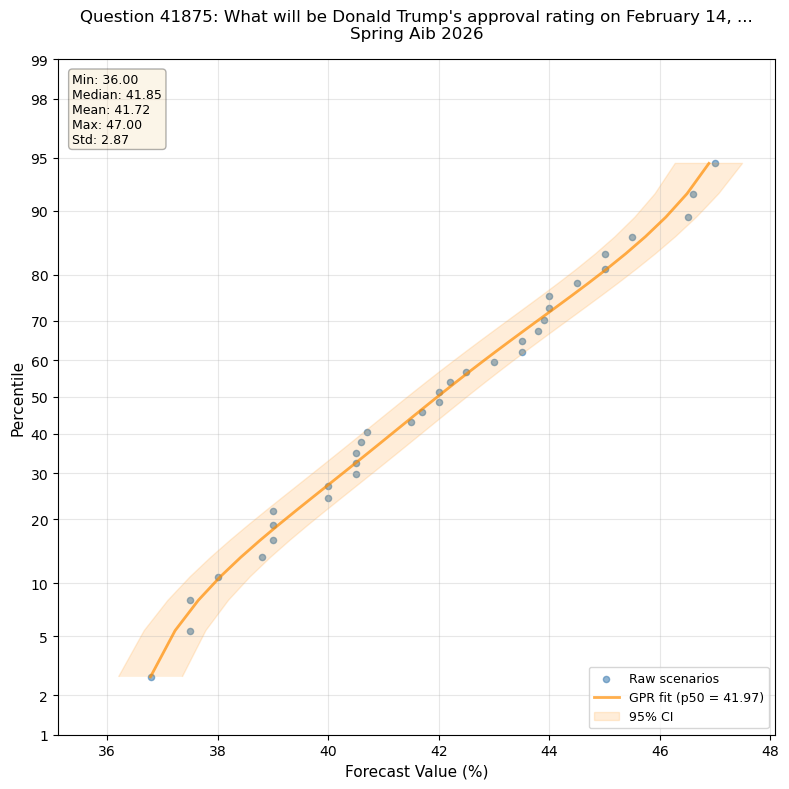


✓ All plots generated


In [6]:
# Generate plots for all questions

print("Generating cumulative distribution plots...")
print("=" * 80)
print()

for qid in question_ids:
    if qid not in all_question_data:
        print(f"Skipping question {qid} (no data)")
        continue
    
    data = all_question_data[qid]
    
    # Process the data
    sorted_data = make_sorted_data(data['raw_values'])
    pctl = make_percentiles(sorted_data)
    
    # Fit GPR model if enabled
    gp_model = None
    if use_gpr_smoothing:
        try:
            gp_model = make_gpr_model(sorted_data, pctl)
        except Exception as e:
            print(f"Warning: GPR fitting failed for question {qid}: {e}")
    
    # Plot
    plot_forecast_distribution(
        question_id=qid,
        sorted_data=sorted_data,
        pctl=pctl,
        gp_model=gp_model,
        metadata=data['metadata'],
        summary=data['summary'],
        aggregated=data['aggregated'],
        use_prob_scale=use_prob_scale
    )

print("\n✓ All plots generated")

## Comparative Analysis (Optional)

Compare distributions across all questions.

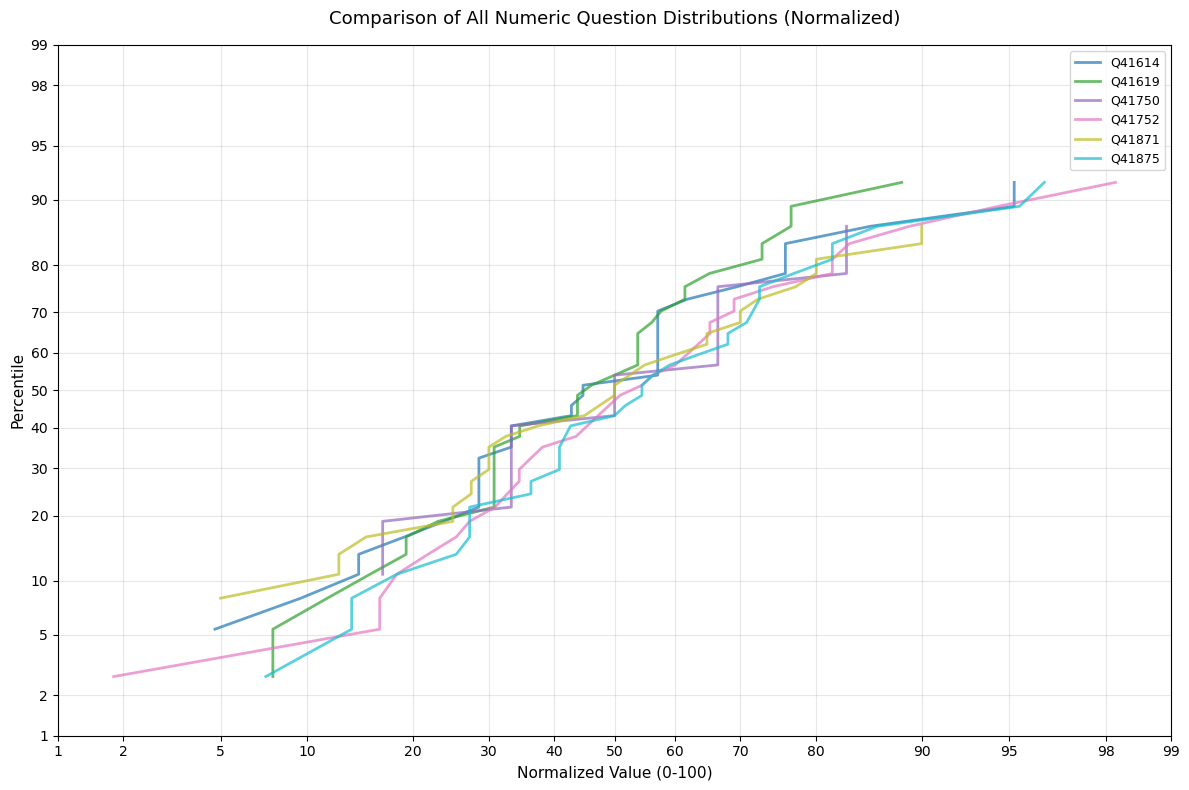

In [7]:
# Optional: Create a comparison plot showing all distributions together

fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(question_ids)))

for idx, qid in enumerate(question_ids):
    if qid not in all_question_data:
        continue
    
    data = all_question_data[qid]
    sorted_data = make_sorted_data(data['raw_values'])
    pctl = make_percentiles(sorted_data)
    
    # Normalize to 0-100 scale for comparison
    min_val = min(sorted_data)
    max_val = max(sorted_data)
    normalized = [(x - min_val) / (max_val - min_val) * 100 for x in sorted_data]
    
    ax.plot(normalized, pctl, linewidth=2, alpha=0.7, 
            label=f'Q{qid}', color=colors[idx])

ax.set_xlabel("Normalized Value (0-100)", fontsize=11)
ax.set_ylabel("Percentile", fontsize=11)
ax.set_title("Comparison of All Numeric Question Distributions (Normalized)", fontsize=13, pad=15)

if use_prob_scale:
    ax.set_xscale('prob')
    ax.set_yscale('prob')
    ax.set_xlim(left=1, right=99)
    ax.set_ylim(bottom=1, top=99)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Summary Statistics Table

In [8]:
# Create a summary table of all questions

summary_data = []

for qid in question_ids:
    if qid not in all_question_data:
        continue
    
    data = all_question_data[qid]
    summary = data['summary']
    metadata = data['metadata']
    
    summary_data.append({
        'Question ID': qid,
        'Tournament': metadata.get('tournament', 'Unknown'),
        'Units': metadata.get('units', ''),
        'N Scenarios': len(data['raw_values']),
        'Min': summary['min_value'],
        'P25': summary.get('p25_value', np.percentile(data['raw_values'], 25)),
        'Median': summary['median_value'],
        'P75': summary.get('p75_value', np.percentile(data['raw_values'], 75)),
        'Max': summary['max_value'],
        'Mean': summary['mean_value'],
        'Std Dev': summary['std_value']
    })

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.round(2)

print("\nSummary Statistics for All Numeric Questions:")
print("=" * 120)
display(df_summary)

# Export to CSV
output_file = data_path.parent / 'numeric_forecast_summary_statistics.csv'
df_summary.to_csv(output_file, index=False)
print(f"\n✓ Summary statistics saved to: {output_file}")


Summary Statistics for All Numeric Questions:


,Question ID,Tournament,Units,N Scenarios,Min,P25,Median,P75,Max,Mean,Std Dev
0,41614,Unknown,Percent,36,4.250000e+00,4.550000e+00,4.710000e+00,4.860000e+00,5.300000e+00,4.730000e+00,2.800000e-01
1,41619,Unknown,Percent,36,4.250000e+00,4.650000e+00,4.820000e+00,5.010000e+00,5.550000e+00,4.820000e+00,3.100000e-01
2,41750,Spring Aib 2026,%,36,1.400000e+01,1.450000e+01,1.475000e+01,1.500000e+01,1.550000e+01,1.473000e+01,4.400000e-01
3,41752,Spring Aib 2026,ppm,36,4.295000e+02,4.312800e+02,4.322500e+02,4.333000e+02,4.350000e+02,4.323100e+02,1.460000e+00
4,41871,Spring Aib 2026,$,36,6.000000e+09,6.537500e+09,6.975000e+09,7.412500e+09,8.000000e+09,6.961111e+09,6.011691e+08
5,41875,Spring Aib 2026,%,36,3.600000e+01,3.975000e+01,4.185000e+01,4.392000e+01,4.700000e+01,4.172000e+01,2.870000e+00



✓ Summary statistics saved to: C:\Users\Donni\projects\metac_bot_Spring_2026\numeric_forecast_summary_statistics.csv
